# Project 2: Spam Classification: Applying SMS Detection Techniques to Email Datasets

- Objective: To develop a text classification model that identifies spam emails. It aims to filter unwanted communication and protect users from phishing and scaam attempts.
- Technical components:
    - Exploratory Analysis: Visiualization of class distribution, word count differences and presence of spam indicators (currency symbols, numbers).
    - Preprocessing: Text cleaning, stopword removal and lemmatization to normalize the emails.
    - Machine Learning: Comparison of Multinomial Naive Bayes and Decision Tree classifiers.
    - Evaluation: Measuring model success with Precision, Recall, F1-score and Confusion Matrix to ensure the model is reliable for spam detection.

## Importing Libraries

In [1]:
# Import Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Importing the Dataset
from datasets import load_dataset

In [3]:
# Standard Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# Text Preprocessing and NLP Libraries
import re         # Regular expressions for cleaning raw data
import nltk       # Provides stopwords and lemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to C:\Users\Ishita
[nltk_data]     Deshmukh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ishita
[nltk_data]     Deshmukh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
# Data Preparation
from sklearn.feature_extraction.text import TfidfVectorizer      # Converts text into numerical vectors
from sklearn.model_selection import cross_val_score, train_test_split

In [6]:
# Model Training and Performance Evaluation
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Data Importing and Analysis

In [7]:
hf_dataset = load_dataset("SetFit/enron_spam")
train_df = hf_dataset['train'].to_pandas()
test_df = hf_dataset['test'].to_pandas()
dataset = pd.concat([train_df, test_df], ignore_index = True)
# Drop all other columns so dataset only has label and text columns
dataset = dataset[['label', 'text']]
# Replace NaN values with empty string
dataset['text'] = dataset['text'].fillna('') 
# Text column is already the addition of subject and message column
# spam and ham are already mapped to 1 and 0
# Rename text to message
dataset = dataset.rename(columns={'text': 'message'})
# Drop duplicates to avoid the model learning the same examples multiple times
dataset = dataset.drop_duplicates(subset = 'message')
dataset = dataset.reset_index(drop = True)
dataset

Repo card metadata block was not found. Setting CardData to empty.


,label,message
0,1,any software just for 15 $ - 99 $ understandin...
1,0,perspective on ferc regulatory action client c...
2,1,wanted to try ci 4 lis but thought it was way ...
3,0,"enron / hpl actuals for december 11 , 2000 tec..."
4,1,looking for cheap high - quality software ? ro...
...,...,...
30458,0,re : book notes vince : look forward to meetin...
30459,0,rollout schedule for unify real - time deal / ...
30460,0,anshuman shrivastava sandeep : vince has asked...
30461,0,"re : good morning john ,\ni shall see christie..."


In [8]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 30463 entries, 0 to 30462
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    30463 non-null  int64
 1   message  30463 non-null  str  
dtypes: int64(1), str(1)
memory usage: 43.4 MB


In [9]:
dataset.describe(include = 'all')

,label,message
count,30463.000000,30463
unique,NaN,30463
top,NaN,any software just for 15 $ - 99 $ understandin...
freq,NaN,1
mean,0.477727,NaN
std,0.499512,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,1.000000,NaN


In [10]:
dataset.isnull().sum()
# Confirms no remaining missing values 

label      0
message    0
dtype: int64

### Visualizing Target Variables and Checking for Class Imbalance

In [11]:
# Check class balance
# Heavily imbalanced dataset would bias the model towards the majority class
dataset['label'].value_counts()

label
0    15910
1    14553
Name: count, dtype: int64

In [12]:
# Calculate the percentage of spam messages in the dataset
dataset['label'].mean() * 100

np.float64(47.7727078751272)

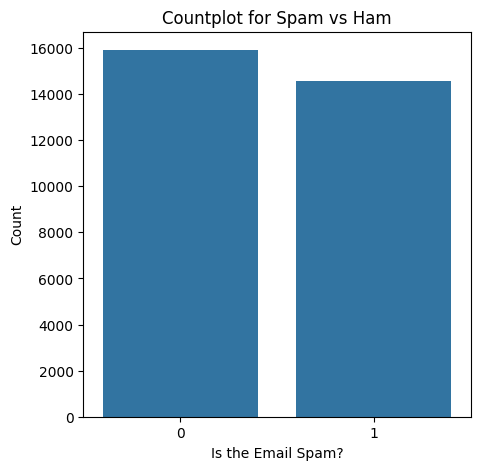

In [13]:
# Countplot for Spam vs Ham
plt.figure(figsize = (5, 5))
g = sns.countplot(x = "label", data = dataset)
p = plt.title('Countplot for Spam vs Ham')
p = plt.xlabel('Is the Email Spam?')
p = plt.ylabel('Count')

Observations:
- The dataset is slightly imbalanced as there are more ham (0) essages than spam (1).
- The model should prioritise high Recall for spam to avoid missing actual spam messages.

### Exploring Spam Indicators

#### Word Count

In [14]:
# Creating new feature: word_count
# Spam emails often have a different length of message 
dataset['word_count'] = dataset['message'].apply(lambda x: len(x.split()))
dataset

,label,message,word_count
0,1,any software just for 15 $ - 99 $ understandin...,33
1,0,perspective on ferc regulatory action client c...,239
2,1,wanted to try ci 4 lis but thought it was way ...,55
3,0,"enron / hpl actuals for december 11 , 2000 tec...",33
4,1,looking for cheap high - quality software ? ro...,71
...,...,...,...
30458,0,re : book notes vince : look forward to meetin...,111
30459,0,rollout schedule for unify real - time deal / ...,229
30460,0,anshuman shrivastava sandeep : vince has asked...,191
30461,0,"re : good morning john ,\ni shall see christie...",277


##### Visualizing Word Count Distributions for Ham and Spam

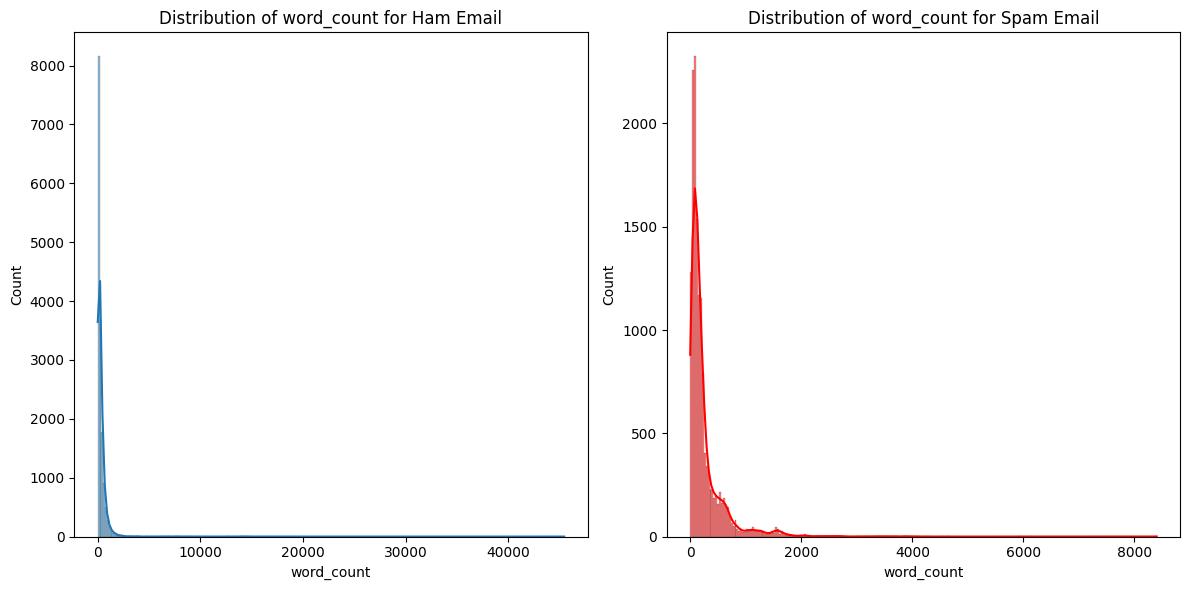

In [15]:
plt.figure(figsize = (12, 6))

# (1, 1)
plt.subplot(1, 2, 1)
g = sns.histplot(dataset[dataset["label"] == 0].word_count, kde = True)
p = plt.title('Distribution of word_count for Ham Email')

# (1, 2)
plt.subplot(1, 2, 2)
g = sns.histplot(dataset[dataset["label"] == 1].word_count, color = "red", kde = True)
p = plt.title('Distribution of word_count for Spam Email')

plt.tight_layout()
plt.show()

Observations: 
- Hams emails have a wide range of word count.
- Spam emails tend to be shorter and more concentrated at lower word counts. They are brief and direct.
- This is not a sufficient direct indicator of spam but it is a useful supporting feature.

#### Currency Symbols

In [16]:
# Creating new feature: contains_currency_symbols to check if the message has any currency symbols
# Spam emails often contain currency symbols (financial offers)
def currency_present(data):
    currency_symbols = ['$', '€', '£', '¥',	'₹']
    for i in currency_symbols:
        if i in data:
            return 1
    return 0
dataset["contains_currency_symbols"] = dataset["message"].apply(currency_present)
dataset

,label,message,word_count,contains_currency_symbols
0,1,any software just for 15 $ - 99 $ understandin...,33,1
1,0,perspective on ferc regulatory action client c...,239,0
2,1,wanted to try ci 4 lis but thought it was way ...,55,1
3,0,"enron / hpl actuals for december 11 , 2000 tec...",33,0
4,1,looking for cheap high - quality software ? ro...,71,0
...,...,...,...,...
30458,0,re : book notes vince : look forward to meetin...,111,0
30459,0,rollout schedule for unify real - time deal / ...,229,0
30460,0,anshuman shrivastava sandeep : vince has asked...,191,0
30461,0,"re : good morning john ,\ni shall see christie...",277,0


##### Visualizing the Correlation of Currency Symbols with Spam and Ham Emails

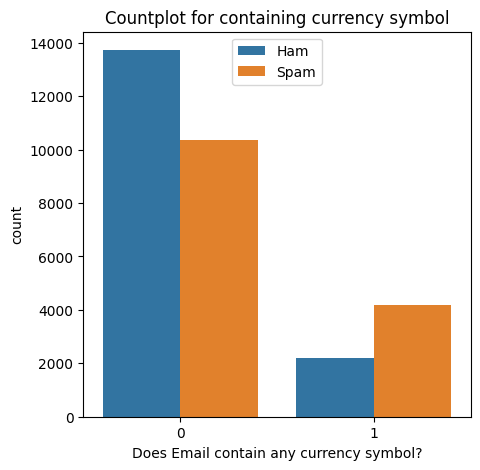

In [17]:
plt.figure(figsize = (5, 5))
g = sns.countplot(x = 'contains_currency_symbols', data = dataset, hue = "label")
p = plt.title('Countplot for containing currency symbol')
p = plt.xlabel('Does Email contain any currency symbol?')
p = plt.ylabel('count')
p = plt.legend(labels = ["Ham", "Spam"], loc = 9)

Observations: 
- Emails without currency symbols are mostly ham, showing that currency symbols are a useful spam indicator.
- Among emails that do contain currency symbols, spam is proportionally much higher than ham.
- But some ham emails also contain currency symbols (e.g. salary discussions, invoices), so this feature alone cannot be used to classify spam.

#### Contains Numbers

In [18]:
# Creating new feature: contains_number
# Spam emails many times contain numbers
def number(data):
    for i in data:
        if ord(i) in range(48, 58):   # ASCII values for digits 0 to 9
            return 1
    return 0
dataset["contains_number"] = dataset['message'].apply(number)
dataset

,label,message,word_count,contains_currency_symbols,contains_number
0,1,any software just for 15 $ - 99 $ understandin...,33,1,1
1,0,perspective on ferc regulatory action client c...,239,0,1
2,1,wanted to try ci 4 lis but thought it was way ...,55,1,1
3,0,"enron / hpl actuals for december 11 , 2000 tec...",33,0,1
4,1,looking for cheap high - quality software ? ro...,71,0,0
...,...,...,...,...,...
30458,0,re : book notes vince : look forward to meetin...,111,0,1
30459,0,rollout schedule for unify real - time deal / ...,229,0,1
30460,0,anshuman shrivastava sandeep : vince has asked...,191,0,1
30461,0,"re : good morning john ,\ni shall see christie...",277,0,1


##### Visualizing Correlation of Numbers with Ham and Spam

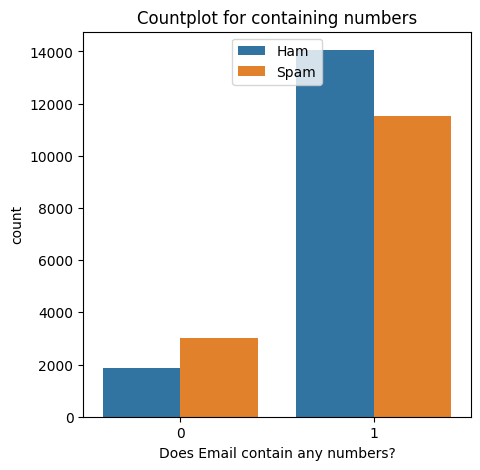

In [19]:
# Countplot for containing numbers
plt.figure(figsize = (5, 5))
g = sns.countplot(x = 'contains_number', data = dataset, hue = "label")
p = plt.title('Countplot for containing numbers')
p = plt.xlabel('Does Email contain any numbers?')
p = plt.ylabel('count')
p = plt.legend(labels = ["Ham", "Spam"], loc = 9)

Observations:
- Almost all emails (both ham and spam) contain numbers, so it is not sufficient to conclude spam.
- Emails with no numbers are almost mostly ham, which is a useful indicator.

## Data Cleaning

### Corpus

In [20]:
# Corpus: a list of preprocessed emails
stop_words = set(stopwords.words('english'))
corpus = []
wnl = WordNetLemmatizer()
for email in list(dataset.message):
    email = str(email)
    message = re.sub(pattern = '[^a-zA-Z]', repl = ' ', string = email)   # Remove all non-alphabetic characters
    message = message.lower()      # Lowercase all words
    words = message.split()
    filtered_words = [word for word in words if word not in stop_words]    # Remove all stopwords (eg. the, is)
    lemm_words = [wnl.lemmatize(word) for word in filtered_words]      # Lemmatize: reduce words to their base form
    message = ' '.join(lemm_words)
    corpus.append(message)

In [21]:
# Check if the messages are cleaned
corpus

['software understanding oem software lead temptation find way law disregard trifle',
 'perspective ferc regulatory action client conf call today jun e th pm edt perspective ferc regulatory action client conference call today tuesday june th pm edt host ray nile power natural gas analyst speaker steve bergstrom president coo dynegy steve bergstrom president chief operating officer dynegy join u p today conference call discussion recent ferc action imposing price control west discussion followed q question explored include implication ferc action dyn industry whole earnings impact risk regulation whatever else mind attach two recent note ferc action reference call replay reservation u u int l int l replay pm raymond c nile power natural gas research salomon smith barney ray nile ssmb com',
 'wanted try ci li thought way expensive viagra per dose ready boost sex life positive time right order viagra incredibly low price per dose unbelivable remove',
 'enron hpl actuals december teco tap 

### Creating bag of words model

In [22]:
tfidf = TfidfVectorizer(max_features = 10000, sublinear_tf = True, min_df = 2, max_df = 0.85, 
                        ngram_range = (1,2))     # Converts cleaned text into a matrix
vectors = tfidf.fit_transform(corpus).toarray()
feature_names = tfidf.get_feature_names_out()

In [23]:
X = pd.DataFrame(vectors, columns = feature_names)
# y is the target variable
y = dataset['label']

In [24]:
# Splitting into training (80%) and testing(20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_test

,aa,ab,abacha,abandoned,abb,abel,abidjan,abiiity,ability,able,...,zimin lu,zip,zipper,zone,zone www,zonedubai,zonedubai uae,zu,zufferli,zyban
10990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26786,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14742,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22672,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1192,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7261,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model Building

### 1. Multinomial Naives Bayes Model

In [25]:
mnb = MultinomialNB()
cv = cross_val_score(mnb, X, y, scoring = 'f1', cv = 10)
print(round(cv.mean(), 3))
print(round(cv.std(), 3))

0.982
0.002


In [26]:
# Training the model on the training set and evaluating on the unseen test set
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3177
           1       0.98      0.98      0.98      2916

    accuracy                           0.98      6093
   macro avg       0.98      0.98      0.98      6093
weighted avg       0.98      0.98      0.98      6093



Observations:
- Overall accuracy (98%)
- Both ham and spam have identical Precision, Recall and F1-score so the model is strong at iidentifying both the cases.

In [27]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[3128,   49],
       [  49, 2867]])

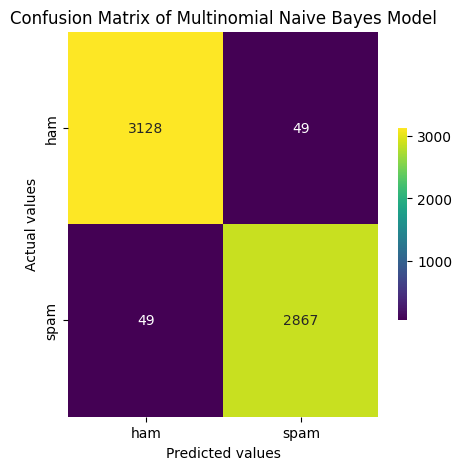

In [28]:
plt.figure(figsize = (5, 5))
axis_labels = ['ham', 'spam']
g = sns.heatmap(data = cm, xticklabels = axis_labels, yticklabels = axis_labels, annot = True, 
                fmt = 'g', cbar_kws = {"shrink" : 0.5}, cmap = "viridis")
p = plt.title("Confusion Matrix of Multinomial Naive Bayes Model")
p = plt.xlabel('Predicted values')
p = plt.ylabel('Actual values')

Observations:
- It has very few spam missed cases due to the low False Negative.

### 2. Decision Tree Classifier

In [29]:
dt = DecisionTreeClassifier(max_depth = 10, min_samples_split = 10, min_samples_leaf = 5, random_state = 42)
cv1 = cross_val_score(dt, X, y, scoring = 'f1', cv = 10)
print(round(cv1.mean(), 3))
print(round(cv1.std(), 3))

0.916
0.005


In [30]:
# Training on the training set and evaluating on the unseen test set
dt.fit(X_train, y_train)
y_pred1 = dt.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.96      0.87      0.92      3177
           1       0.87      0.97      0.92      2916

    accuracy                           0.92      6093
   macro avg       0.92      0.92      0.92      6093
weighted avg       0.92      0.92      0.92      6093



Observations:
- Overall accuracy (92%): High but much lower than Naive bayes.
- It misses 13% of actual ham emails.

In [31]:
cm1 = confusion_matrix(y_test, y_pred1)
cm1

array([[2769,  408],
       [ 102, 2814]])

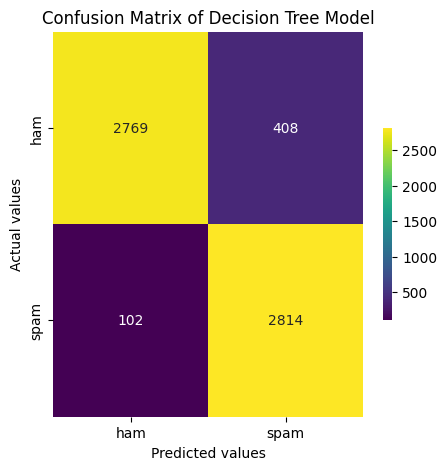

In [32]:
plt.figure(figsize=(5, 5))
axis_labels = ['ham', 'spam']
g = sns.heatmap(data=cm1, xticklabels=axis_labels, yticklabels=axis_labels,
                annot=True, fmt='g', cbar_kws={"shrink": 0.5}, cmap="viridis")
p = plt.title("Confusion Matrix of Decision Tree Model")
p = plt.xlabel('Predicted values')
p = plt.ylabel('Actual values')

Observations:
- More False Positives and False Negatives compared to Naive Bayes.
- This model is more likely to misclassify ham as spam.

### Observations of the Naive Bayes and Decision Tree Models:
- Naive Bayes has a higher and more consistent F1 score.
- Naive Bayes is clearly a stronger model for spam detaction.
- It is also faster, making it more practical for real time email filtering.

## Live Prediction Function

In [33]:
# Applies the same preprocessing steps used during training to a new email and returns the Neive Bayes model's prediction (1 = Spam, 0 = Ham)
def predict_spam(subject = '', body = ''):
    email_message = str(subject) + ' ' + str(body)
    message = re.sub(pattern = '[^a-zA-Z]', repl = ' ', string = email_message)
    message = message.lower()
    words = message.split()
    filtered_words = [word for word in words if word not in set(stopwords.words('english'))]
    lemm_words = [wnl.lemmatize(word) for word in filtered_words]
    message = ' '.join(lemm_words)
    temp = tfidf.transform([message]).toarray()
    return mnb.predict(temp)

### Testing the Model on Sample Emails

In [34]:
# Test Case 1: Clear spam
sample_subject = 'Claim your compensation now'
sample_body = 'You could be entitled up to $3,160 in compensation from mis-sold PPI on a credit card or loan. Reply PPI for info or STOP to opt out.'
if predict_spam(subject = sample_subject, body = sample_body):
    print('Alert! This is a SPAM email!')
else:
    print('This is a HAM (normal) email.')

Alert! This is a SPAM email!


In [35]:
# Test Case 2: Clear ham
sample_subject = 'Catching up'
sample_body = 'Hi, hope you are doing well. Just wanted to check in and see how the project is going. Let me know if you need anything from my end. Talk soon.'
if predict_spam(subject = sample_subject, body = sample_body):
    print('Alert! This is a SPAM email!')
else:
    print('This is a HAM (normal) email.')

This is a HAM (normal) email.


In [36]:
# Test Case 3: Ham with currency 
sample_subject = 'Rent payment received'
sample_body = 'Sam, your rent payment for Jan 19 has been received. $1,300 will be drafted from your Wells Fargo account ******'
if predict_spam(subject = sample_subject, body = sample_body):
    print('Alert! This is a SPAM email!')
else:
    print('This is a HAM (normal) email.')

This is a HAM (normal) email.
